## Imports and Setup

In [1]:
import torch
torch.cuda.empty_cache() 

In [2]:
torch.cuda.set_device(1)

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from transformers import LlamaTokenizer, LlamaForCausalLM
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/b22cs092/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [5]:
import torch
torch.cuda.empty_cache()

In [6]:
print("GPUs Available:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

GPUs Available: 1
GPU 0: NVIDIA L40S


In [7]:
print(torch.cuda.current_device())  # Index of the current device

1


In [8]:
!nvidia-smi

Tue Sep 30 14:37:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    Off |   00000000:61:00.0 Off |                    0 |
| N/A   22C    P8             31W /  350W |      14MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
dataset = load_dataset('wikitext', 'wikitext-2-raw-v1')

print("Sample from WikiText-2:")
for i in range(5):
    print(f"Example {i}: {repr(dataset['train'][i]['text'][:100])}...")

Sample from WikiText-2:
Example 0: ''...
Example 1: ' = Valkyria Chronicles III = \n'...
Example 2: ''...
Example 3: ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battle'...
Example 4: ' The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chr'...


### Tokenizer

In [10]:
def tokenize_function(examples):
    inputs = tokenizer(
        examples['text'], 
        truncation=True, 
        padding='max_length', 
        max_length=512,
        return_attention_mask=True,
    )
    inputs['labels'] = inputs['input_ids'].copy()
    return inputs

In [11]:
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2").to(device)



In [12]:
# Set the EOS token as the padding token
tokenizer.pad_token = tokenizer.eos_token

In [13]:
model.config.pad_token_id = tokenizer.pad_token_id

In [14]:
tokenized_datasets = dataset.map(tokenize_function, batched=True)

In [15]:
tokenized_datasets

DatasetDict({
    test: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3760
    })
})

In [16]:
pip install 'accelerate>=0.26.0'  --break-system-packages --user

Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install openpyxl --break-system-packages --user

Note: you may need to restart the kernel to use updated packages.


In [18]:
!pip install sentencepiece --break-system-packages --user

In [19]:
print(type(model))


<class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'>


In [20]:
print(tokenizer.model_max_length)
print(tokenizer.padding_side)


1024
right


In [21]:
import time
import numpy as np
import pandas as pd

In [22]:
!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [23]:
!nvidia-smi

Tue Sep 30 14:37:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    Off |   00000000:61:00.0 Off |                    0 |
| N/A   22C    P8             31W /  350W |      14MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:
!ps -u -p 530187,3319341,449911

USER         PID %CPU %MEM    VSZ   RSS TTY      STAT START   TIME COMMAND


In [25]:
tokenized_datasets = dataset.map(tokenize_function, batched=True)

In [26]:
tokenized_datasets

DatasetDict({
    test: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3760
    })
})

In [27]:
import gc
torch.cuda.empty_cache()
gc.collect()

95

## Inference

In [28]:
model_output_llama_dir = 'kv/results_llama/model'

In [29]:
model_output_gpt2_dir='kv/results/model'

In [30]:
gpt2_tokenizer = AutoTokenizer.from_pretrained(model_output_gpt2_dir)
gpt2_model = AutoModelForCausalLM.from_pretrained(model_output_gpt2_dir).to(device)
gpt2_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [31]:
test_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
modified_prompts = []

for example in test_dataset:
    text = example['text'].strip()
    if len(text) > 200 and not text.startswith('='):
        words = text.split()
        if len(words) > 200:
            partial_text = ' '.join(words[:200])  # First 100 words
            modified_prompts.append(partial_text)


prompt_texts = modified_prompts

In [32]:
import numpy as np
import random
def set_all_seeds(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Before each generation
set_all_seeds(42)

In [33]:
import time
import numpy as np
import pandas as pd

 KV caching improves throughput and lowers latency

In [34]:
!pip install plotly --break-system-packages --user

In [35]:
from datetime import datetime
import torch, time, numpy as np, pandas as pd
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import math

# This function correctly calculates perplexity using YOUR fine-tuned model.
def calculate_perplexity(model, tokenizer, text_list, device="cuda"):
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    for text in text_list:
        if not text:
            continue

        encodings = tokenizer(text, return_tensors="pt")
        input_ids = encodings.input_ids.to(device)

        # Copy and mask padding tokens for loss calculation
        target_ids = input_ids.clone()
        target_ids[target_ids == tokenizer.pad_token_id] = -100  

        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            loss = outputs.loss

            # count only valid tokens (exclude masked ones)
            num_tokens = (target_ids != -100).sum().item()
            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    if total_tokens == 0:
        return float("inf")

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity

def get_tensor_size_bytes(tensor):
    return tensor.numel() * tensor.element_size()

def inference(model, tokenizer, device, prompt_texts, name):
    all_results = []
    
    # --- ADDITION: Variables for Speedup Calculation ---
    cached_throughput = 0
    cached_avg_latency = 0

    # Warmup (Original code preserved)
    print("Warming up model...")
    warmup_inputs = tokenizer("Hello", return_tensors="pt").to(device)
    for use_cache_warmup in [False, True]:
        for _ in range(2):
            with torch.no_grad():
                model.generate(**warmup_inputs, max_new_tokens=5, use_cache=use_cache_warmup)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    print("Warmup complete\n")

    for use_cache in (True, False):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

        times = []
        total_generated_tokens = 0
        print(f"--- Evaluating with KV cache = {use_cache} ---")

        captured_kv_history = []
        hooks = []
        if not use_cache:
            def make_hook(layer_id):
                def hook(module, input, output):
                    hidden_states = input[0]
                    q, k, v = module.c_attn(hidden_states).split(module.split_size, dim=2)
                    captured_kv_history.append({
                        "layer": layer_id, "k_shape": tuple(k.shape), "v_shape": tuple(v.shape),
                        "k_mem": get_tensor_size_bytes(k), "v_mem": get_tensor_size_bytes(v)
                    })
                return hook
            for i, block in enumerate(model.transformer.h):
                h = block.attn.register_forward_hook(make_hook(i))
                hooks.append(h)

        for i, prompt in enumerate(prompt_texts):
            inputs = tokenizer(prompt, return_tensors="pt").to(device)
            input_len = inputs["input_ids"].shape[1]
            # --- Original print statements preserved ---
            print("Prompt: ", prompt) 
            print(f"Input tokens: {input_len}")
            torch.manual_seed(42)
            captured_kv_history.clear()

            with torch.no_grad():
                start = time.time()
                outputs = model.generate(
                    **inputs, use_cache=use_cache, max_new_tokens=50, min_new_tokens=5,
                    do_sample=False, temperature=1.0, pad_token_id=tokenizer.eos_token_id,
                    return_dict_in_generate=True, output_scores=True
                )
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                elapsed = time.time() - start

            output_len = outputs.sequences.shape[1]
            generated_tokens = output_len - input_len
            total_generated_tokens += generated_tokens
            times.append(elapsed)
            generated_text = tokenizer.decode(outputs.sequences[0][input_len:], skip_special_tokens=True)

            # --- Original print statements preserved ---
            print(f"Generated tokens: {generated_tokens}")
            print(f"Time taken: {elapsed:.3f} seconds")
            print(f"Generated part only: {repr(generated_text)}")
            print("-"*50)

            total_kv_bytes = 0
            if use_cache:
                past_key_values = outputs.past_key_values
                # --- Original print statements preserved ---
                print("\nKV Cache Shapes and Sizes per Layer (final state):")
                for layer_idx, (k, v) in enumerate(past_key_values):
                    layer_bytes = get_tensor_size_bytes(k) + get_tensor_size_bytes(v)
                    total_kv_bytes += layer_bytes
                    print(f"  Layer {layer_idx}: K {k.shape}, V {v.shape}, Size: {layer_bytes/1024:.2f} KiB")
                print(f"Total KV Cache Size: {total_kv_bytes/1024:.2f} KiB\n")
            else:
                # --- Original print statements preserved ---
                print("\nKV Shapes and Sizes per Layer (captured at each step):")
                stepwise = {}
                for record in captured_kv_history:
                    layer = record["layer"]
                    kv_size = (record["k_mem"] + record["v_mem"])
                    stepwise.setdefault(layer, []).append(kv_size)
                
                for layer, sizes in stepwise.items():
                    print(f"  Layer {layer}: step KV sizes (KiB) = {[round(s / 1024, 2) for s in sizes]}")
                    total_kv_bytes += sum(sizes)
                print(f"Total KV Computation Across All Steps/Layers: {total_kv_bytes/1024/1024:.2f} MiB\n")
            
            # --- REVERTED TO ORIGINAL SAVING FORMAT ---
            result_row = {
                'cache_enabled': use_cache,
                'prompt_id': i,
                'prompt_text': prompt[:100] + "..." if len(prompt) > 100 else prompt,
                'input_tokens': input_len,
                'generated_tokens': generated_tokens,
                'total_tokens': output_len,
                'time_taken_sec': round(elapsed, 3),
                'kv_cache_size_kib': round(total_kv_bytes/1024, 2) if total_kv_bytes > 0 else 'N/A',
                'generated_part': generated_text[:200] + "..." if len(generated_text) > 200 else generated_text
            }
            all_results.append(result_row)
        
        for h in hooks: h.remove()
        
        avg_latency = np.mean(times)
        std_latency = np.std(times)
        total_time = sum(times)
        throughput = total_generated_tokens / total_time if total_time > 0 else 0
        
        print(f"\nSummary for cache_enabled={use_cache}:")
        print(f"Average Latency: {avg_latency:.3f} ± {std_latency:.3f} sec")
        print(f"Throughput: {throughput:.2f} tokens/sec")

        # Calculate perplexity for this run
        print("Calculating perplexity...")
        perplexity_score = calculate_perplexity(model, tokenizer, prompt_texts, device)
        print(f"Perplexity on input prompts: {perplexity_score:.4f}")

        # --- REVERTED TO ORIGINAL SUMMARY ROW FORMAT ---
        summary_row = {
            'cache_enabled': use_cache, 'prompt_id': 'SUMMARY', 'prompt_text': f'Summary for cache={use_cache}',
            'input_tokens': '', 'generated_tokens': total_generated_tokens, 'total_tokens': '',
            'time_taken_sec': round(total_time, 3), 'kv_cache_size_kib': '',
            'avg_latency_sec': round(avg_latency, 3), 'std_latency_sec': round(std_latency, 3),
            'throughput_tokens_per_sec': round(throughput, 2),
            'avg_perplexity': round(perplexity_score, 4) if perplexity_score != float('inf') else 'N/A',
            'generated_part': f'Total generated: {total_generated_tokens} tokens'
        }
        all_results.append(summary_row)

        if use_cache:
            cached_throughput = throughput
            cached_avg_latency = avg_latency
        else:
            print("-" * 20)
            if cached_throughput > 0 and throughput > 0:
                throughput_speedup = cached_throughput / throughput
                print(f"--> Throughput Speedup Factor: {throughput_speedup:.2f}x")
            if cached_avg_latency > 0 and avg_latency > 0:
                latency_speedup = avg_latency / cached_avg_latency
                print(f"--> Average Latency Speedup Factor: {latency_speedup:.2f}x")
        print("="*60 + "\n")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"kv_cache_results_{name}_{timestamp}.xlsx"
    df = pd.DataFrame(all_results)
    df.fillna('', inplace=True)
    df.to_excel(filename, index=False)
    print(f"Results saved to {filename}")
  

In [51]:
inference(gpt2_model, gpt2_tokenizer, device=device, prompt_texts=prompt_texts[:10], name="gpt2")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Warming up model...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Warmup complete

--- Evaluating with KV cache = True ---
Prompt:  Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre . He had a guest role in the television series Judge John Deed in 2002 . In 2004 Boulter landed a role as " Craig " in the episode " Teddy 's Story " of the television series The Long Firm ; he starred alongside actors
Input tokens: 109
Generated tokens: 7
Time taken: 0.081 seconds
Generated part only: ' from the show . \n'
--------------------------------------------------

KV Cache Shapes and Sizes per Layer (final state):
  Layer 0: K torch.Size([1, 12, 115, 64]), V torch.Size([1, 12, 115, 64]), Size: 690.00 KiB
  Layer 1: K torch.Size([1, 12, 115, 64]), V torch.Size([1, 12, 115, 64]), Size: 690.00 KiB
  Layer 2: K torch.Size([1, 12, 115, 6

/tmp/ipykernel_1356052/1444335062.py:200: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('', inplace=True)


In [57]:
from datetime import datetime
import torch, time, numpy as np, pandas as pd
from transformers import LlamaForCausalLM, LlamaTokenizer
import math

# This function correctly calculates perplexity using YOUR model.
# It is modael-agnostic and works for Llama as well.
def calculate_perplexity(model, tokenizer, text_list, device="cuda"):
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    for text in text_list:
        if not text:
            continue

        encodings = tokenizer(text, return_tensors="pt")
        input_ids = encodings.input_ids.to(device)

        target_ids = input_ids.clone()
        target_ids[target_ids == tokenizer.pad_token_id] = -100  

        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            loss = outputs.loss
            num_tokens = (target_ids != -100).sum().item()
            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    if total_tokens == 0:
        return float("inf")

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity

def get_tensor_size_bytes(tensor):
    return tensor.numel() * tensor.element_size()

def llama_inference(model, tokenizer, device, prompt_texts, name):
    all_results = []
    
    # --- ADDITION: Variables for Speedup Calculation ---
    cached_throughput = 0
    cached_avg_latency = 0

    # Warmup (Original code preserved)
    print("Warming up model...")
    warmup_inputs = tokenizer("Hello", return_tensors="pt").to(device)
    for use_cache_warmup in [False, True]:
        for _ in range(2):
            with torch.no_grad():
                model.generate(**warmup_inputs, max_new_tokens=5, use_cache=use_cache_warmup)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    print("Warmup complete\n")

    for use_cache in (True, False):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

        times = []
        total_generated_tokens = 0
        all_predictions = []
        print(f"--- Evaluating with KV cache = {use_cache} ---")

        captured_kv_history = []
        hooks = []
        
        # Original Llama-specific hook logic preserved
        if not use_cache:
            def make_hook_for_layernorm(attn_module, layer_id):
                def hook(module, args, output):
                    hidden_states = output
                    q = attn_module.q_proj(hidden_states)
                    k = attn_module.k_proj(hidden_states)
                    v = attn_module.v_proj(hidden_states)
                    captured_kv_history.append({
                        "layer": layer_id, "k_shape": tuple(k.shape), "v_shape": tuple(v.shape),
                        "k_mem": get_tensor_size_bytes(k), "v_mem": get_tensor_size_bytes(v)
                    })
                return hook

            for i, layer in enumerate(model.model.layers):
                h = layer.input_layernorm.register_forward_hook(
                    make_hook_for_layernorm(layer.self_attn, i)
                )
                hooks.append(h)

        for i, prompt in enumerate(prompt_texts[:100]):
            inputs = tokenizer(prompt, return_tensors="pt").to(device)
            input_len = inputs["input_ids"].shape[1]
            print("Prompt: ", prompt)
            print(f"Input tokens: {input_len}")
            torch.manual_seed(42)
            captured_kv_history.clear()

            with torch.no_grad():
                start = time.time()
                outputs = model.generate(
                    **inputs, use_cache=use_cache, max_new_tokens=50, min_new_tokens=5,
                    do_sample=False, temperature=1.0, pad_token_id=tokenizer.eos_token_id,
                    return_dict_in_generate=True, output_scores=True
                )
                # --- FIX: ADD GPU SYNC FOR ACCURATE TIMING ---
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                elapsed = time.time() - start

            output_len = outputs.sequences.shape[1]
            generated_tokens = output_len - input_len
            total_generated_tokens += generated_tokens
            times.append(elapsed)

            full_text = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True)
            generated_text = tokenizer.decode(outputs.sequences[0][input_len:], skip_special_tokens=True)
            all_predictions.append(full_text)

            print(f"Generated tokens: {generated_tokens}")
            print(f"Time taken: {elapsed:.3f} seconds")
            print(f"Generated part only: {repr(generated_text)}")
            print("-"*50)
            
            total_kv_bytes = 0
            if use_cache:
                past_key_values = outputs.past_key_values
                print("\nKV Cache Shapes and Sizes per Layer (final state):")
                for layer_idx, (k, v) in enumerate(past_key_values):
                    layer_bytes = get_tensor_size_bytes(k) + get_tensor_size_bytes(v)
                    total_kv_bytes += layer_bytes
                    print(f"  Layer {layer_idx}: K {k.shape}, V {v.shape}, Size: {layer_bytes/1024:.2f} KiB")
                print(f"Total KV Cache Size: {total_kv_bytes/1024:.2f} KiB\n")
            else:
                print("\nKV Shapes and Sizes per Layer (captured at each step):")
                stepwise = {}
                for record in captured_kv_history:
                    layer = record["layer"]
                    kv_size = (record["k_mem"] + record["v_mem"])
                    stepwise.setdefault(layer, []).append(kv_size)
                
                for layer, sizes in stepwise.items():
                    print(f"  Layer {layer}: step KV sizes (KiB) = {[round(s / 1024, 2) for s in sizes]}")
                    total_kv_bytes += sum(sizes)
                
                print(f"Total KV Computation Across All Steps/Layers: {total_kv_bytes/1024/1024:.2f} MiB\n")
            
            # --- Saving format preserved as requested ---
            result_row = {
                'cache_enabled': use_cache, 'prompt_id': i,
                'prompt_text': prompt[:100] + "..." if len(prompt) > 100 else prompt,
                'input_tokens': input_len, 'generated_tokens': generated_tokens,
                'total_tokens': output_len, 'time_taken_sec': round(elapsed, 3),
                'kv_cache_size_kib': round(total_kv_bytes/1024, 2) if total_kv_bytes > 0 else 'N/A',
                'generated_part': generated_text[:200] + "..." if len(generated_text) > 200 else generated_text
            }
            all_results.append(result_row)
            
        for h in hooks:
            h.remove()
        
        avg_latency = np.mean(times) if times else 0
        std_latency = np.std(times) if times else 0
        total_time = sum(times)
        throughput = (total_generated_tokens / total_time) if total_time > 0 else 0
        
        print(f"\nSummary for cache_enabled={use_cache}:")
        print(f"Latency: {round(avg_latency, 3)} ± {round(std_latency, 3)} sec")
        print(f"Throughput: {round(throughput, 2)} tokens/sec")

        # --- FIX: Correct perplexity calculation for YOUR Llama model ---
        print(f"Calculating perplexity for cache={use_cache}...")
        avg_perplexity = calculate_perplexity(model, tokenizer, prompt_texts[:100], device)
        print(f"Average Perplexity: {avg_perplexity:.4f}")

        # --- Saving format preserved as requested ---
        summary_row = {
            'cache_enabled': use_cache, 'prompt_id': 'SUMMARY',
            'prompt_text': f'Summary for cache={use_cache}', 'input_tokens': '',
            'generated_tokens': total_generated_tokens, 'total_tokens': '',
            'time_taken_sec': round(total_time, 3), 'kv_cache_size_kib': '',
            'avg_latency_sec': round(avg_latency, 3), 'std_latency_sec': round(std_latency, 3),
            'throughput_tokens_per_sec': round(throughput, 2),
            'avg_perplexity': round(avg_perplexity, 4) if avg_perplexity != float('inf') else 'N/A',
            'generated_part': f'Total generated: {total_generated_tokens} tokens'
        }
        all_results.append(summary_row)

        # --- ADDITION: Speedup calculation ---
        if use_cache:
            cached_throughput = throughput
            cached_avg_latency = avg_latency
        else:
            print("-" * 20)
            if cached_throughput > 0 and throughput > 0:
                throughput_speedup = cached_throughput / throughput
                print(f"--> Throughput Speedup Factor: {throughput_speedup:.2f}x")
            if cached_avg_latency > 0 and avg_latency > 0:
                latency_speedup = avg_latency / cached_avg_latency
                print(f"--> Average Latency Speedup Factor: {latency_speedup:.2f}x")
        print("="*60 + "\n")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"kv_cache_results_{name}_{timestamp}.xlsx"
    df = pd.DataFrame(all_results)
    df.to_excel(filename, index=False)
    print(f"Results saved to {filename}")

In [58]:
llama_inference(llama_model, llama_tokenizer, device=device, prompt_texts=prompt_texts[:10], name="llama")

Warming up model...
Warmup complete

--- Evaluating with KV cache = True ---
Prompt:  Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre . He had a guest role in the television series Judge John Deed in 2002 . In 2004 Boulter landed a role as " Craig " in the episode " Teddy 's Story " of the television series The Long Firm ; he starred alongside actors
Input tokens: 133


From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.


Generated tokens: 11
Time taken: 0.271 seconds
Generated part only: 'who had previously appeared in the series . \n'
--------------------------------------------------

KV Cache Shapes and Sizes per Layer (final state):
  Layer 0: K torch.Size([1, 4, 143, 64]), V torch.Size([1, 4, 143, 64]), Size: 286.00 KiB
  Layer 1: K torch.Size([1, 4, 143, 64]), V torch.Size([1, 4, 143, 64]), Size: 286.00 KiB
  Layer 2: K torch.Size([1, 4, 143, 64]), V torch.Size([1, 4, 143, 64]), Size: 286.00 KiB
  Layer 3: K torch.Size([1, 4, 143, 64]), V torch.Size([1, 4, 143, 64]), Size: 286.00 KiB
  Layer 4: K torch.Size([1, 4, 143, 64]), V torch.Size([1, 4, 143, 64]), Size: 286.00 KiB
  Layer 5: K torch.Size([1, 4, 143, 64]), V torch.Size([1, 4, 143, 64]), Size: 286.00 KiB
  Layer 6: K torch.Size([1, 4, 143, 64]), V torch.Size([1, 4, 143, 64]), Size: 286.00 KiB
  Layer 7: K torch.Size([1, 4, 143, 64]), V torch.Size([1, 4, 143, 64]), Size: 286.00 KiB
  Layer 8: K torch.Size([1, 4, 143, 64]), V torch.Size([1, 4

### BENCHMARK RESULTS

In [38]:
import torch
import time
import numpy as np
import pandas as pd
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from evaluate import load
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components
from datetime import datetime
import math


## GPT2

In [39]:
# --- 1. Utility Functions ---
from datetime import datetime
import torch
import time
import numpy as np
import pandas as pd
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import math
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components
import numpy as np


def calculate_perplexity(model, tokenizer, text_list, device="cuda"):
    """Calculates perplexity by evaluating the model's loss on the input text."""
    model.eval()
    total_loss = 0
    total_tokens = 0
    for text in text_list:
        if not text:
            continue
        encodings = tokenizer(text, return_tensors="pt")
        input_ids = encodings.input_ids.to(device)
        target_ids = input_ids.clone()
        target_ids[target_ids == tokenizer.pad_token_id] = -100
        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            loss = outputs.loss
            # count only valid tokens (exclude masked ones)
            num_tokens = (target_ids != -100).sum().item()
            if num_tokens > 0:
                total_loss += loss.item() * num_tokens
                total_tokens += num_tokens
    if total_tokens == 0:
        return float("inf")
    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity


def get_tensor_size_bytes(tensor):
    return tensor.numel() * tensor.element_size()


# --- 2. Graph-Based Compression Module ---

class CompressionModule:
    """Handles the compression and decompression of KV cache tensors."""
    def __init__(self, epsilon, device):
        self.epsilon = epsilon
        self.device = device

    def _compress_single_tensor(self, tensor_state):
        num_heads, seq_len, head_dim = tensor_state.shape
        if seq_len <= 1:
            return ([tensor_state[h].unsqueeze(0) for h in range(num_heads)],
                    [torch.zeros(seq_len, dtype=torch.long, device=self.device) for _ in range(num_heads)])

        all_head_centroids, all_head_mappings = [], []
        for h in range(num_heads):
            head_tensor = tensor_state[h, :, :].cpu().numpy()
            distances = squareform(pdist(head_tensor, 'euclidean'))
            adjacency_matrix = distances < self.epsilon
            n_components, labels = connected_components(csgraph=adjacency_matrix, directed=False, return_labels=True)

            centroids = np.zeros((n_components, head_dim))
            for i in range(n_components):
                cluster_nodes = head_tensor[labels == i]
                if cluster_nodes.shape[0] > 0:
                    centroids[i] = cluster_nodes.mean(axis=0)

            all_head_centroids.append(torch.tensor(centroids, dtype=tensor_state.dtype, device=self.device))
            all_head_mappings.append(torch.tensor(labels, dtype=torch.long, device=self.device))
        return all_head_centroids, all_head_mappings

    def _decompress_single_tensor(self, centroids_list, mappings_list):
        decompressed_heads = [centroids[mapping] for centroids, mapping in zip(centroids_list, mappings_list)]
        return torch.stack(decompressed_heads)

    def compress_kv_cache(self, past_key_values):
        return [(self._compress_single_tensor(k.squeeze(0)), self._compress_single_tensor(v.squeeze(0))) for k, v in past_key_values]

    def decompress_kv_cache(self, compressed_cache):
        return tuple((self._decompress_single_tensor(*k).unsqueeze(0), self._decompress_single_tensor(*v).unsqueeze(0)) for k, v in compressed_cache)


# --- 3. Main Benchmark Orchestrator ---

def run_benchmark(model, tokenizer, prompt_texts, name="gpt2"):
    """Runs a benchmark comparing standard, no-cache, and a smarter compressed cache."""
    device = model.device
    epsilon = 2.0
    COMPRESSION_INTERVAL = 5
    compression_module = CompressionModule(epsilon=epsilon, device=device)
    max_new_tokens = 50
    all_results = []

    print(f"Benchmark Settings: Epsilon={epsilon}, Compression Interval={COMPRESSION_INTERVAL} tokens")

    # --- Warmup ---
    print("Warming up model...")
    warmup_inputs = tokenizer("Hello", return_tensors="pt").to(device)
    for use_cache_warmup in [False, True]:
        for _ in range(2):
            with torch.no_grad():
                model.generate(**warmup_inputs, max_new_tokens=5, use_cache=use_cache_warmup)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    print("Warmup complete\n")

    modes_to_test = ['compressed_cache', 'standard_cache', 'no_cache']
    cached_throughput, cached_avg_latency = 0, 0

    for mode in modes_to_test:
        print(f"--- Evaluating with Mode: {mode.upper()} ---")
        times, total_generated_tokens = [], 0
        
        generated_texts_for_ppl = []

        hooks = []
        if mode == 'no_cache':
            def make_hook(layer_id):
                def hook(module, input, output):
                    hidden_states = input[0]
                    q, k, v = module.c_attn(hidden_states).split(module.split_size, dim=2)
                    captured_kv_history.append({"layer": layer_id, "k_mem": get_tensor_size_bytes(k), "v_mem": get_tensor_size_bytes(v)})
                return hook
            for i, block in enumerate(model.transformer.h):
                h = block.attn.register_forward_hook(make_hook(i))
                hooks.append(h)

        for i, prompt in enumerate(prompt_texts):
            inputs = tokenizer(prompt, return_tensors="pt").to(device)
            input_len = inputs.input_ids.shape[1]
            
            print(f"Prompt: {i} ", prompt)
            print(f"Input tokens: {input_len}")

            torch.manual_seed(42)
            captured_kv_history = []
            
            compressed = None

            start_time = time.time()
            with torch.no_grad():
                if mode == 'compressed_cache':
                    input_ids = inputs.input_ids
                    past_key_values = None
                    for step in range(max_new_tokens):
                        model_inputs = {'input_ids': input_ids[:, -1:], 'past_key_values': past_key_values, 'use_cache': True} if past_key_values else {'input_ids': input_ids}
                        outputs = model(**model_inputs)
                        next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(-1)
                        input_ids = torch.cat([input_ids, next_token], dim=-1)
                        if next_token.item() == tokenizer.eos_token_id:
                            break
                        past_key_values = outputs.past_key_values
                        if (step + 1) % COMPRESSION_INTERVAL == 0:
                            compressed = compression_module.compress_kv_cache(past_key_values)
                            past_key_values = compression_module.decompress_kv_cache(compressed)
                    sequences = input_ids
                else:
                    use_cache_flag = (mode == 'standard_cache')
                    outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, min_new_tokens=5, use_cache=use_cache_flag,
                                           do_sample=False, pad_token_id=tokenizer.eos_token_id,
                                           return_dict_in_generate=True, output_scores=True)
                    sequences = outputs.sequences

            if torch.cuda.is_available():
                torch.cuda.synchronize()
            elapsed_time = time.time() - start_time

            generated_tokens = sequences.shape[1] - input_len
            total_generated_tokens += generated_tokens
            times.append(elapsed_time)
            
            full_generated_text = tokenizer.decode(sequences[0], skip_special_tokens=True)
            generated_part_text = tokenizer.decode(sequences[0][input_len:], skip_special_tokens=True)
            generated_texts_for_ppl.append(full_generated_text)

            print(f"Generated tokens: {generated_tokens}")
            print(f"Time taken: {elapsed_time:.3f} seconds")
            print(f"Generated part only: {repr(generated_part_text)}")
            print("-" * 50)

            # --- Per-prompt data collection ---
            total_kv_bytes = 0
            if mode == 'standard_cache':
                print("\nKV Cache Shapes and Sizes per Layer (final state):")
                past_key_values = outputs.past_key_values
                for layer_idx, (k, v) in enumerate(past_key_values):
                    layer_bytes = get_tensor_size_bytes(k) + get_tensor_size_bytes(v)
                    total_kv_bytes += layer_bytes
                    print(f"  Layer {layer_idx}: K {k.shape}, V {v.shape}, Size: {layer_bytes/1024:.2f} KiB")
                print(f"Total KV Cache Size: {total_kv_bytes/1024:.2f} KiB\n")
            
            elif mode == 'compressed_cache':
                if compressed:
                    print("\nKV Cache Sizes per Layer (COMPRESSED state):")
                    for layer_idx, (compressed_k, compressed_v) in enumerate(compressed):
                        k_centroids_bytes = sum(get_tensor_size_bytes(t) for t in compressed_k[0])
                        k_mappings_bytes = sum(get_tensor_size_bytes(t) for t in compressed_k[1])
                        v_centroids_bytes = sum(get_tensor_size_bytes(t) for t in compressed_v[0])
                        v_mappings_bytes = sum(get_tensor_size_bytes(t) for t in compressed_v[1])
                        layer_bytes = k_centroids_bytes + k_mappings_bytes + v_centroids_bytes + v_mappings_bytes
                        total_kv_bytes += layer_bytes
                        num_k_centroids = sum(c.shape[0] for c in compressed_k[0])
                        num_v_centroids = sum(c.shape[0] for c in compressed_v[0])
                        seq_len = compressed_k[1][0].shape[0]
                        print(f"  Layer {layer_idx}: K (centroids={num_k_centroids}, seq={seq_len}), V (centroids={num_v_centroids}, seq={seq_len}), Size: {layer_bytes/1024:.2f} KiB")
                    print(f"Total COMPRESSED KV Cache Size: {total_kv_bytes/1024:.2f} KiB\n")
                else:
                     print("\nNo compression was applied in this run (sequence too short).\n")

            elif mode == 'no_cache':
                print("\nKV Shapes and Sizes per Layer (captured at each step):")
                stepwise = {}
                for record in captured_kv_history:
                    layer = record["layer"]
                    kv_size = (record["k_mem"] + record["v_mem"])
                    stepwise.setdefault(layer, []).append(kv_size)
                    total_kv_bytes += kv_size
                for layer, sizes in stepwise.items():
                    print(f"  Layer {layer}: step KV sizes (KiB) = {[round(s / 1024, 2) for s in sizes]}")
                print(f"Total KV Computation Across All Steps/Layers: {total_kv_bytes/1024/1024:.2f} MiB\n")

            ## MODIFIED ## - Switched to the more detailed dictionary structure for saving to Excel.
            output_len = sequences.shape[1]
            result_row = {
                'mode': mode,
                'prompt_id': i,
                'prompt_text': prompt[:100] + "..." if len(prompt) > 100 else prompt,
                'input_tokens': input_len,
                'generated_tokens': generated_tokens,
                'total_tokens': output_len,
                'time_taken_sec': round(elapsed_time, 3),
                'kv_cache_size_kib': round(total_kv_bytes/1024, 2) if total_kv_bytes > 0 else 'N/A',
                'generated_part': generated_part_text[:200] + "..." if len(generated_part_text) > 200 else generated_part_text
            }
            all_results.append(result_row)


        for h in hooks: h.remove()

        # --- Mode Summary Calculation ---
        avg_latency, std_latency, total_time = np.mean(times), np.std(times), sum(times)
        throughput = total_generated_tokens / total_time if total_time > 0 else 0
        
        print("Calculating perplexity on generated texts...")
        perplexity_score = calculate_perplexity(model, tokenizer, generated_texts_for_ppl, device)

        print(f"\nSummary for mode={mode}:")
        print(f"Average Latency: {avg_latency:.3f} ± {std_latency:.3f} sec")
        print(f"Throughput: {throughput:.2f} tokens/sec")
        print(f"Perplexity on generated outputs: {perplexity_score:.4f}")
        print("="*60 + "\n")

        ## MODIFIED ## - Switched to the more detailed dictionary structure for the summary row.
        summary_row = {
            'mode': mode, 'prompt_id': 'SUMMARY', 'prompt_text': f'Summary for mode={mode}',
            'input_tokens': '', 'generated_tokens': total_generated_tokens, 'total_tokens': '',
            'time_taken_sec': round(total_time, 3), 'kv_cache_size_kib': '',
            'avg_latency_sec': round(avg_latency, 3), 'std_latency_sec': round(std_latency, 3),
            'throughput_tokens_per_sec': round(throughput, 2),
            'avg_perplexity': round(perplexity_score, 4) if perplexity_score != float('inf') else 'N/A',
            'generated_part': f'Total generated: {total_generated_tokens} tokens'
        }
        all_results.append(summary_row)


        if mode == 'standard_cache':
            cached_throughput, cached_avg_latency = throughput, avg_latency
        elif mode == 'no_cache':
            print("-" * 20)
            if cached_throughput > 0 and throughput > 0:
                print(f"--> Throughput Speedup Factor (standard vs no-cache): {cached_throughput / throughput:.2f}x")
            if cached_avg_latency > 0 and avg_latency > 0:
                latency_speedup = avg_latency / cached_avg_latency
                print(f"--> Average Latency Speedup Factor: {latency_speedup:.2f}x")

    # --- Save Final Report ---
    df = pd.DataFrame(all_results).fillna('')
    filename = f"benchmark_results_{name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
    df.to_excel(filename, index=False)
    print(f"Benchmark complete. Results saved to {filename}")

In [40]:
run_benchmark(gpt2_model, gpt2_tokenizer, prompt_texts[:10], name="gpt2")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Benchmark Settings: Epsilon=2.0, Compression Interval=5 tokens
Warming up model...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Warmup complete

--- Evaluating with Mode: COMPRESSED_CACHE ---
Prompt: 0  Boulter starred in two films in 2008 , Daylight Robbery by filmmaker Paris Leonti , and Donkey Punch directed by Olly Blackburn . Boulter portrayed a character named " Sean " in Donkey Punch , who tags along with character " Josh " as the " quiet brother ... who hits it off with Tammi " . Boulter guest starred on a two @-@ part episode arc " Wounds " in May 2008 of the television series Waking the Dead as character " Jimmy Dearden " . He appeared on the television series Survivors as " Neil " in November 2008 . He had a recurring role in ten episodes of the television series Casualty in 2010 , as " Kieron Fletcher " . He portrayed an emergency physician applying for a medical fellowship . He commented on the inherent difficulties in portraying a physician on television : " Playing a doctor is a strange experience . Pretending you know what you 're talking about when you don 't is very bizarre but there are advis

# Optimized

In [41]:
pip install cugraph-cu12 cudf-cu12 --extra-index-url=https://pypi.nvidia.com --break-system-packages --user

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [42]:
# --- 1. Utility Functions ---
from datetime import datetime
import torch
import time
import numpy as np
import pandas as pd
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import math
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components
import numpy as np
import matplotlib.pyplot as plt

@torch._dynamo.disable
def calculate_perplexity(model, tokenizer, text_list, device="cuda"):
    """Calculates perplexity by evaluating the model's loss on the input text."""
    model.eval()
    total_loss = 0
    total_tokens = 0
    for text in text_list:
        if not text:
            continue
        encodings = tokenizer(text, return_tensors="pt")
        input_ids = encodings.input_ids.to(device)
        target_ids = input_ids.clone()
        target_ids[target_ids == tokenizer.pad_token_id] = -100
        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            loss = outputs.loss
            num_tokens = (target_ids != -100).sum().item()
            if num_tokens > 0:
                total_loss += loss.item() * num_tokens
                total_tokens += num_tokens
    if total_tokens == 0:
        return float("inf")
    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity


def get_tensor_size_bytes(tensor):
    return tensor.numel() * tensor.element_size()


# --- 2. Graph-Based Compression Module ---

import torch
import math

class CompressionModule:
    """
    Handles KV cache compression using a synchronized token pruning strategy.
    It clusters the KEY vectors, finds a representative token for each cluster,
    and then uses the indices of those tokens to prune BOTH the key and value
    tensors. This ensures their sequence lengths always match.
    """
    def __init__(self, epsilon, device, clustering_iterations=10):
        self.epsilon = epsilon
        self.device = device
        self.clustering_iterations = clustering_iterations

    def _gpu_connected_components(self, adj_matrix):
        # This helper function remains the same.
        num_heads, seq_len, _ = adj_matrix.shape
        labels = torch.arange(seq_len, device=self.device, dtype=torch.long)
        labels = labels.unsqueeze(0).expand(num_heads, -1)
        adj_matrix_with_loops = adj_matrix | torch.eye(
            seq_len, device=self.device, dtype=torch.bool
        ).unsqueeze(0)

        for _ in range(self.clustering_iterations):
            propagated_labels = torch.where(
                adj_matrix_with_loops, labels.unsqueeze(1), seq_len
            )
            min_neighbor_labels = torch.min(propagated_labels, dim=2).values
            new_labels = torch.min(labels, min_neighbor_labels)
            if torch.equal(labels, new_labels):
                break
            labels = new_labels
        return labels

    def _prune_kv_pair(self, k_state, v_state):
        # --- NEW: This function now takes both k and v tensors ---
        # It will perform all calculations based on k_state and apply the
        # resulting indices to both k_state and v_state.
        
        num_heads, seq_len, head_dim = k_state.shape

        if seq_len <= 1:
            return k_state, v_state

        # --- Steps 1-3: Cluster KEY vectors and find centroids ---
        distances = torch.cdist(k_state, k_state)
        adjacency_matrix = distances < self.epsilon
        labels = self._gpu_connected_components(adjacency_matrix)

        all_remapped_labels, all_num_components = [], []
        for h in range(num_heads):
            unique_h, inverse_h = torch.unique(labels[h], return_inverse=True)
            all_remapped_labels.append(inverse_h)
            all_num_components.append(unique_h.size(0))
        remapped_labels = torch.stack(all_remapped_labels)
        max_components = max(all_num_components)

        remapped_labels_expanded = remapped_labels.unsqueeze(-1).expand(-1, -1, head_dim)
        summed_centroids = torch.zeros(
            (num_heads, max_components, head_dim),
            dtype=k_state.dtype, device=self.device,
        )
        summed_centroids.scatter_add_(1, remapped_labels_expanded, k_state)
        ones = torch.ones_like(k_state)
        counts = torch.zeros_like(summed_centroids)
        counts.scatter_add_(1, remapped_labels_expanded, ones)
        centroids = summed_centroids / counts.clamp(min=1)

        # --- Step 4: Find Representative Token Indices from KEY vectors ---
        centroids_for_each_token = torch.gather(
            centroids, 1, remapped_labels_expanded
        )
        dist_to_centroids = torch.sum(
            (k_state - centroids_for_each_token)**2, dim=-1
        )
        cluster_indices = torch.arange(
            max_components, device=self.device
        ).view(1, -1, 1)
        mask = remapped_labels.unsqueeze(1) != cluster_indices
        masked_distances = torch.where(
            mask, torch.tensor(float('inf'), device=self.device), dist_to_centroids.unsqueeze(1)
        )
        representative_indices = torch.argmin(masked_distances, dim=-1)

        # --- Step 5: Prune BOTH K and V Tensors with the SAME Indices ---
        indices_expanded = representative_indices.unsqueeze(-1).expand(-1, -1, head_dim)
        
        pruned_k = torch.gather(k_state, 1, indices_expanded)
        pruned_v = torch.gather(v_state, 1, indices_expanded) # Use same indices for V
        
        return pruned_k, pruned_v

    def compress_kv_cache(self, past_key_values):
        # The list comprehension now calls the new _prune_kv_pair method.
        return [
            self._prune_kv_pair(k.squeeze(0), v.squeeze(0))
            for k, v in past_key_values
        ]

# --- 3. MODIFIED BENCHMARK ORCHESTRATOR ---

def run_single_benchmark(model, tokenizer, prompt_texts, mode, device, 
                         epsilon=2.0, compression_interval=5, max_new_tokens=50):
    """
    Runs a benchmark for a SINGLE mode and returns a dictionary of summary results
    along with a list of per-prompt results.
    """
    print(f"--- Evaluating with Mode: {mode.upper()} (Epsilon: {epsilon if mode=='compressed_cache' else 'N/A'}) ---")
    
    compression_module = CompressionModule(epsilon=epsilon, device=device)
    times, total_generated_tokens = [], 0
    generated_texts_for_ppl = []
    all_prompt_results = []
    
    hooks = []
    if mode == 'no_cache':
        def make_hook(layer_id):
            def hook(module, input, output):
                hidden_states = input[0]
                q, k, v = module.c_attn(hidden_states).split(module.split_size, dim=2)
                captured_kv_history.append({"layer": layer_id, "k_mem": get_tensor_size_bytes(k), "v_mem": get_tensor_size_bytes(v)})
            return hook
        for i, block in enumerate(model.transformer.h):
            h = block.attn.register_forward_hook(make_hook(i))
            hooks.append(h)

    for i, prompt in enumerate(prompt_texts):
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        input_len = inputs.input_ids.shape[1]
        
        print(f"Prompt: {i} ", prompt)
        print(f"Input tokens: {input_len}")
        
        torch.manual_seed(42)
        captured_kv_history = []
        compressed = None

        start_time = time.time()
        with torch.no_grad():
            if mode == 'compressed_cache':
                input_ids = inputs.input_ids
                past_key_values = None
                for step in range(max_new_tokens):
                    model_inputs = {'input_ids': input_ids[:, -1:], 'past_key_values': past_key_values, 'use_cache': True} if past_key_values else {'input_ids': input_ids}
                    outputs = model(**model_inputs)
                    next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(-1)
                    input_ids = torch.cat([input_ids, next_token], dim=-1)
                    if next_token.item() == tokenizer.eos_token_id:
                        break
                    past_key_values = outputs.past_key_values
                    if (step + 1) % compression_interval == 0:
                        pruned_kv_list = compression_module.compress_kv_cache(past_key_values)
                        
                        # FIX 1: Assign the result to `compressed` to track for printing.
                        compressed = pruned_kv_list
                        
                        past_key_values = tuple(
                            (k.unsqueeze(0), v.unsqueeze(0)) for k, v in pruned_kv_list
                        )
                if past_key_values and not compressed: 
                     pruned_kv_list = compression_module.compress_kv_cache(past_key_values)
                     compressed = pruned_kv_list # Track for logging
                     past_key_values = tuple(
                         (k.unsqueeze(0), v.unsqueeze(0)) for k, v in pruned_kv_list
                     )
                sequences = input_ids
            else:
                use_cache_flag = (mode == 'standard_cache')
                outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, min_new_tokens=5, use_cache=use_cache_flag,
                                       do_sample=False, pad_token_id=tokenizer.eos_token_id,
                                       return_dict_in_generate=True, output_scores=True)
                sequences = outputs.sequences

        if torch.cuda.is_available(): torch.cuda.synchronize()
        elapsed_time = time.time() - start_time
        
        generated_tokens = sequences.shape[1] - input_len
        total_generated_tokens += generated_tokens
        times.append(elapsed_time)
        
        full_generated_text = tokenizer.decode(sequences[0], skip_special_tokens=True)
        generated_part_text = tokenizer.decode(sequences[0][input_len:], skip_special_tokens=True)
        generated_texts_for_ppl.append(full_generated_text)

        print(f"Generated tokens: {generated_tokens}")
        print(f"Time taken: {elapsed_time:.3f} seconds")
        print(f"Generated part only: {repr(generated_part_text)}")
        print("-" * 50)
        
        total_kv_bytes = 0
        if mode == 'standard_cache':
            print("\nKV Cache Shapes and Sizes per Layer (final state):")
            past_key_values = outputs.past_key_values
            for layer_idx, (k, v) in enumerate(past_key_values):
                layer_bytes = get_tensor_size_bytes(k) + get_tensor_size_bytes(v)
                total_kv_bytes += layer_bytes
                print(f"  Layer {layer_idx}: K {k.shape}, V {v.shape}, Size: {layer_bytes/1024:.2f} KiB")
            print(f"Total KV Cache Size: {total_kv_bytes/1024:.2f} KiB\n")
        
        elif mode == 'compressed_cache':
            if compressed:
                # FIX 2: Correctly calculate and print the size of the pruned tensors.
                print("\nKV Cache Sizes per Layer (COMPRESSED state):")
                for layer_idx, (pruned_k, pruned_v) in enumerate(compressed):
                    layer_bytes = get_tensor_size_bytes(pruned_k) + get_tensor_size_bytes(pruned_v)
                    total_kv_bytes += layer_bytes
                    # Get shape for printing (pruned_k has shape [heads, new_seq_len, dim])
                    new_seq_len = pruned_k.shape[1] 
                    print(f"  Layer {layer_idx}: Pruned to seq_len={new_seq_len}, Size: {layer_bytes/1024:.2f} KiB")
                print(f"Total COMPRESSED KV Cache Size: {total_kv_bytes/1024:.2f} KiB\n")
            else:
                print("\nNo compression was applied in this run (sequence too short).\n")
        
        elif mode == 'no_cache':
            print("\nKV Shapes and Sizes per Layer (captured at each step):")
            stepwise = {}
            for record in captured_kv_history:
                layer = record["layer"]
                kv_size = (record["k_mem"] + record["v_mem"])
                stepwise.setdefault(layer, []).append(kv_size)
                total_kv_bytes += kv_size
            for layer, sizes in stepwise.items():
                print(f"  Layer {layer}: step KV sizes (KiB) = {[round(s / 1024, 2) for s in sizes]}")
            print(f"Total KV Computation Across All Steps/Layers: {total_kv_bytes/1024/1024:.2f} MiB\n")
        
        output_len = sequences.shape[1]
        result_row = {
            'mode': mode, 'epsilon': epsilon if mode == 'compressed_cache' else 'N/A', 'prompt_id': i,
            'prompt_text': prompt[:100] + "..." if len(prompt) > 100 else prompt,
            'input_tokens': input_len, 'generated_tokens': generated_tokens, 'total_tokens': output_len,
            'time_taken_sec': round(elapsed_time, 3),
            'kv_cache_size_kib': round(total_kv_bytes/1024, 2) if total_kv_bytes > 0 else 'N/A',
            'generated_part': generated_part_text[:200] + "..." if len(generated_part_text) > 200 else generated_part_text
        }
        all_prompt_results.append(result_row)

    for h in hooks: h.remove()
    
    avg_latency = np.mean(times) if times else 0
    std_latency = np.std(times) if times else 0
    total_time = sum(times)
    throughput = total_generated_tokens / total_time if total_time > 0 else 0
    
    print("  Calculating perplexity...")
    perplexity_score = calculate_perplexity(model, tokenizer, generated_texts_for_ppl, device)

    summary = {
        'mode': f"SUMMARY_{mode}", 'epsilon': epsilon if mode == 'compressed_cache' else 'N/A',
        'avg_perplexity': round(perplexity_score, 4),
        'throughput_tokens_per_sec': round(throughput, 2),
        'avg_latency_sec': round(avg_latency, 3), 'std_latency_sec': round(std_latency, 3)
    }
    
    print(f"\nSummary for mode={mode} (Epsilon={epsilon if mode=='compressed_cache' else 'N/A'}):")
    print(f"  Average Latency: {avg_latency:.3f} ± {std_latency:.3f} sec")
    print(f"  Throughput: {throughput:.2f} tokens/sec")
    print(f"  Perplexity on generated outputs: {perplexity_score:.4f}")
    print("="*60 + "\n")
    
    return summary, all_prompt_results

## --- 4. NEW Plotting Function --- ##
def plot_results(plot_data, baseline_summary):
    """
    Generates and saves a multi-panel plot of perplexity, throughput, and latency 
    vs. epsilon, comparing against the baseline standard cache performance.
    """
    if not plot_data:
        print("No data available for plotting.")
        return
        
    # --- Extract data for plotting ---
    epsilons = [d['epsilon'] for d in plot_data]
    perplexities = [d['avg_perplexity'] for d in plot_data]
    throughputs = [d['throughput_tokens_per_sec'] for d in plot_data]
    latencies = [d['avg_latency_sec'] for d in plot_data]

    # --- Extract baseline values from the summary dictionary ---
    baseline_perplexity = baseline_summary.get('avg_perplexity')
    baseline_throughput = baseline_summary.get('throughput_tokens_per_sec')
    baseline_latency = baseline_summary.get('avg_latency_sec')

    # --- Create a 1x3 subplot figure ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('KV Cache Compression Performance vs. Epsilon', fontsize=16)

    # --- Plot 1: Perplexity vs. Epsilon ---
    axes[0].plot(epsilons, perplexities, marker='o', linestyle='-', color='b', label='Compressed Cache')
    if baseline_perplexity is not None:
        axes[0].axhline(y=baseline_perplexity, color='r', linestyle='--', 
                        label=f'Standard Cache PPL ({baseline_perplexity:.2f})')
    axes[0].set_title('Model Quality (Perplexity)')
    axes[0].set_xlabel('Epsilon (Clustering Threshold)')
    axes[0].set_ylabel('Perplexity (Lower is Better)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[0].legend()

    # --- Plot 2: Throughput vs. Epsilon ---
    axes[1].plot(epsilons, throughputs, marker='s', linestyle='-', color='g', label='Compressed Cache')
    if baseline_throughput is not None:
        axes[1].axhline(y=baseline_throughput, color='r', linestyle='--', 
                        label=f'Standard Cache Thr. ({baseline_throughput:.2f})')
    axes[1].set_title('System Speed (Throughput)')
    axes[1].set_xlabel('Epsilon (Clustering Threshold)')
    axes[1].set_ylabel('Throughput (tokens/sec, Higher is Better)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[1].legend()

    # --- Plot 3: Latency vs. Epsilon ---
    axes[2].plot(epsilons, latencies, marker='^', linestyle='-', color='purple', label='Compressed Cache')
    if baseline_latency is not None:
        axes[2].axhline(y=baseline_latency, color='r', linestyle='--', 
                        label=f'Standard Cache Lat. ({baseline_latency:.3f})')
    axes[2].set_title('Response Time (Latency)')
    axes[2].set_xlabel('Epsilon (Clustering Threshold)')
    axes[2].set_ylabel('Average Latency (seconds, Lower is Better)')
    axes[2].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    
    # --- Save and show the plot ---
    plot_filename = f"compression_metrics_vs_epsilon_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    plt.savefig(plot_filename)
    print(f"\nMetrics plot saved to {plot_filename}")
    plt.show()


## --- 5. NEW Main Experiment Runner --- ##
def run_full_experiment(model, tokenizer, prompt_texts, name="gpt2"):
    """
    Main orchestrator to run benchmarks over multiple epsilon values and plot results.
    """
    device = model.device
    
    # --- Warmup ---
    print("--- Warming up model... ---")
    warmup_inputs = tokenizer("Hello", return_tensors="pt").to(device)
    for use_cache_warmup in [False, True]:
        for _ in range(2):
            with torch.no_grad():
                model.generate(**warmup_inputs, max_new_tokens=5, use_cache=use_cache_warmup)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    print("Warmup complete\n")

    all_results_df = pd.DataFrame()

    # --- Run Baselines ---
    standard_cache_summary, standard_prompt_results = run_single_benchmark(model, tokenizer, prompt_texts, 'standard_cache', device)
    all_results_df = pd.concat([all_results_df, pd.DataFrame(standard_prompt_results)], ignore_index=True)
    
    no_cache_summary, no_prompt_results = run_single_benchmark(model, tokenizer, prompt_texts, 'no_cache', device)
    all_results_df = pd.concat([all_results_df, pd.DataFrame(no_prompt_results)], ignore_index=True)

    # --- Run Epsilon Sweep for Compressed Cache ---
    epsilon_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0] 
    compression_summaries = []
    
    for epsilon in epsilon_values:
        summary, prompt_results = run_single_benchmark(model, tokenizer, prompt_texts, 'compressed_cache', device,
                                                       epsilon=epsilon, compression_interval=128)
        compression_summaries.append(summary)
        all_results_df = pd.concat([all_results_df, pd.DataFrame(prompt_results)], ignore_index=True)

    # --- Final Plotting ---
    if compression_summaries:
        # Pass the entire summary dictionary for the standard cache to the plot function
        plot_results(compression_summaries, standard_cache_summary)

    # --- Save Full Report ---
    summary_df = pd.DataFrame([standard_cache_summary, no_cache_summary] + compression_summaries)
    
    # Detailed per-prompt report
    detailed_filename = f"detailed_results_{name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
    all_results_df.to_excel(detailed_filename, index=False)
    print(f"Full detailed experiment results saved to {detailed_filename}")
    
    # Summary report
    summary_filename = f"summary_results_{name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
    summary_df.to_excel(summary_filename, index=False)
    print(f"Summary of experiment results saved to {summary_filename}")

In [43]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Fri_Jan__6_16:45:21_PST_2023
Cuda compilation tools, release 12.0, V12.0.140
Build cuda_12.0.r12.0/compiler.32267302_0


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


--- Warming up model... ---


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Warmup complete

--- Evaluating with Mode: STANDARD_CACHE (Epsilon: N/A) ---
Prompt: 0  Boulter starred in two films in 2008 , Daylight Robbery by filmmaker Paris Leonti , and Donkey Punch directed by Olly Blackburn . Boulter portrayed a character named " Sean " in Donkey Punch , who tags along with character " Josh " as the " quiet brother ... who hits it off with Tammi " . Boulter guest starred on a two @-@ part episode arc " Wounds " in May 2008 of the television series Waking the Dead as character " Jimmy Dearden " . He appeared on the television series Survivors as " Neil " in November 2008 . He had a recurring role in ten episodes of the television series Casualty in 2010 , as " Kieron Fletcher " . He portrayed an emergency physician applying for a medical fellowship . He commented on the inherent difficulties in portraying a physician on television : " Playing a doctor is a strange experience . Pretending you know what you 're talking about when you don 't is very bizarre but th

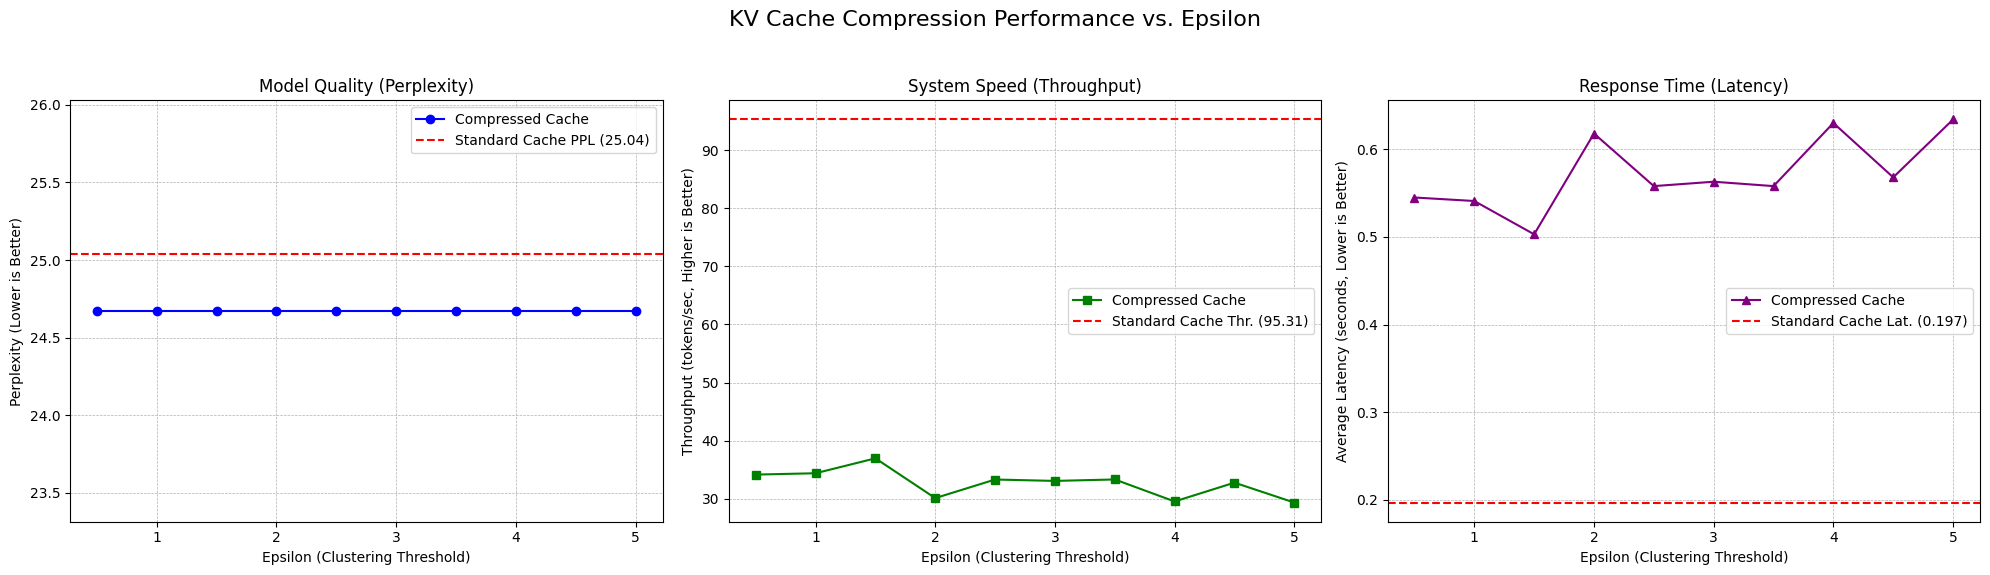

Full detailed experiment results saved to detailed_results_gpt2_20250910_151821.xlsx
Summary of experiment results saved to summary_results_gpt2_20250910_151821.xlsx


In [44]:
run_full_experiment(gpt2_model, gpt2_tokenizer, prompt_texts[:10], name="gpt2")

In [40]:
# --- 1.a Utility Functions (Original) ---
from datetime import datetime
import torch
import time
import numpy as np
import pandas as pd
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import math
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components
import numpy as np
import matplotlib.pyplot as plt

# --- MODIFIED FUNCTION ---
def save_tensors_to_mem_file(cache_data, prefix):
    """
    Saves K and V tensors for each layer into individual .mem files,
    converting their FP32 values to IEEE 754 hex format.
    
    Args:
        cache_data (list of tuples): The past_key_values structure.
        prefix (str): A string for the filenames (e.g., 'standard_cache').
    """
    print(f"\n--- Saving Per-Layer KV Cache to FP32 hex .mem files for prefix: '{prefix}' ---")

    if not cache_data:
        print("  - No cache data provided.")
        return

    # Step 1: Iterate through each layer's K/V pair
    for i, (k_tensor, v_tensor) in enumerate(cache_data):
        
        tensors_to_process = {
            "key": k_tensor,
            "value": v_tensor
        }

        # Step 2: Process the Key and Value tensor for the current layer
        for tensor_name, tensor_data in tensors_to_process.items():
            # Create a unique filename for each layer and tensor type
            filepath = f"NEW_VERILOG_{prefix}_layer_{i}_{tensor_name}.mem"
            
            # Squeeze batch dimension, flatten, and ensure it's FP32 on the CPU
            flat_tensor = tensor_data.squeeze().flatten().to(torch.float32).cpu()
            
            print(f"  - Processing Layer {i} {tensor_name} ({len(flat_tensor)} entries) -> {filepath}")

            # Step 3: Reinterpret the FP32 bits as INT32 to get the IEEE 754 pattern
            int32_representation = flat_tensor.view(torch.int32)

            # Step 4: Write the 8-character hex string for each value
            with open(filepath, 'w') as f:
                for val in int32_representation:
                    hex_val = f'{(val.item() & 0xFFFFFFFF):08x}\n'
                    f.write(hex_val)

    print("--- .mem file export complete ---\n")
    
@torch._dynamo.disable
def calculate_perplexity(model, tokenizer, text_list, device="cuda"):
    """Calculates perplexity by evaluating the model's loss on the input text."""
    model.eval()
    total_loss = 0
    total_tokens = 0
    for text in text_list:
        if not text:
            continue
        encodings = tokenizer(text, return_tensors="pt")
        input_ids = encodings.input_ids.to(device)
        target_ids = input_ids.clone()
        target_ids[target_ids == tokenizer.pad_token_id] = -100
        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            loss = outputs.loss
            num_tokens = (target_ids != -100).sum().item()
            if num_tokens > 0:
                total_loss += loss.item() * num_tokens
                total_tokens += num_tokens
    if total_tokens == 0:
        return float("inf")
    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity


def get_tensor_size_bytes(tensor):
    return tensor.numel() * tensor.element_size()


# --- 2. Graph-Based Compression Module ---

import torch
import math

class CompressionModule:
    """
    Handles KV cache compression using a synchronized token pruning strategy.
    It clusters the KEY vectors, finds a representative token for each cluster,
    and then uses the indices of those tokens to prune BOTH the key and value
    tensors. This ensures their sequence lengths always match.
    """
    def __init__(self, epsilon, device, clustering_iterations=10):
        self.epsilon = epsilon
        self.device = device
        self.clustering_iterations = clustering_iterations

    def _gpu_connected_components(self, adj_matrix):
        # This helper function remains the same.
        num_heads, seq_len, _ = adj_matrix.shape
        labels = torch.arange(seq_len, device=self.device, dtype=torch.long)
        labels = labels.unsqueeze(0).expand(num_heads, -1)
        adj_matrix_with_loops = adj_matrix | torch.eye(
            seq_len, device=self.device, dtype=torch.bool
        ).unsqueeze(0)

        for _ in range(self.clustering_iterations):
            propagated_labels = torch.where(
                adj_matrix_with_loops, labels.unsqueeze(1), seq_len
            )
            min_neighbor_labels = torch.min(propagated_labels, dim=2).values
            new_labels = torch.min(labels, min_neighbor_labels)
            if torch.equal(labels, new_labels):
                break
            labels = new_labels
        return labels

    def _prune_kv_pair(self, k_state, v_state):
        # --- NEW: This function now takes both k and v tensors ---
        # It will perform all calculations based on k_state and apply the
        # resulting indices to both k_state and v_state.
        
        num_heads, seq_len, head_dim = k_state.shape

        if seq_len <= 1:
            return k_state, v_state

        # --- Steps 1-3: Cluster KEY vectors and find centroids ---
        distances = torch.cdist(k_state, k_state)
        adjacency_matrix = distances < self.epsilon
        labels = self._gpu_connected_components(adjacency_matrix)

        all_remapped_labels, all_num_components = [], []
        for h in range(num_heads):
            unique_h, inverse_h = torch.unique(labels[h], return_inverse=True)
            all_remapped_labels.append(inverse_h)
            all_num_components.append(unique_h.size(0))
        remapped_labels = torch.stack(all_remapped_labels)
        max_components = max(all_num_components)

        remapped_labels_expanded = remapped_labels.unsqueeze(-1).expand(-1, -1, head_dim)
        summed_centroids = torch.zeros(
            (num_heads, max_components, head_dim),
            dtype=k_state.dtype, device=self.device,
        )
        summed_centroids.scatter_add_(1, remapped_labels_expanded, k_state)
        ones = torch.ones_like(k_state)
        counts = torch.zeros_like(summed_centroids)
        counts.scatter_add_(1, remapped_labels_expanded, ones)
        centroids = summed_centroids / counts.clamp(min=1)

        # --- Step 4: Find Representative Token Indices from KEY vectors ---
        centroids_for_each_token = torch.gather(
            centroids, 1, remapped_labels_expanded
        )
        dist_to_centroids = torch.sum(
            (k_state - centroids_for_each_token)**2, dim=-1
        )
        cluster_indices = torch.arange(
            max_components, device=self.device
        ).view(1, -1, 1)
        mask = remapped_labels.unsqueeze(1) != cluster_indices
        masked_distances = torch.where(
            mask, torch.tensor(float('inf'), device=self.device), dist_to_centroids.unsqueeze(1)
        )
        representative_indices = torch.argmin(masked_distances, dim=-1)

        # --- Step 5: Prune BOTH K and V Tensors with the SAME Indices ---
        indices_expanded = representative_indices.unsqueeze(-1).expand(-1, -1, head_dim)
        
        pruned_k = torch.gather(k_state, 1, indices_expanded)
        pruned_v = torch.gather(v_state, 1, indices_expanded) # Use same indices for V
        
        return pruned_k, pruned_v

    def compress_kv_cache(self, past_key_values):
        # The list comprehension now calls the new _prune_kv_pair method.
        return [
            self._prune_kv_pair(k.squeeze(0), v.squeeze(0))
            for k, v in past_key_values
        ]

# --- 3. MODIFIED BENCHMARK ORCHESTRATOR ---
# This global list will store the cache tensors we want to export later
captured_cache_for_mem_export = []

def run_single_benchmark(model, tokenizer, prompt_texts, mode, device, 
                         epsilon=2.0, compression_interval=5, max_new_tokens=50):
    """
    Runs a benchmark for a SINGLE mode and returns a dictionary of summary results
    along with a list of per-prompt results.
    """
    print(f"--- Evaluating with Mode: {mode.upper()} (Epsilon: {epsilon if mode=='compressed_cache' else 'N/A'}) ---")
    
    compression_module = CompressionModule(epsilon=epsilon, device=device)
    times, total_generated_tokens = [], 0
    generated_texts_for_ppl = []
    all_prompt_results = []
    
    hooks = []
    if mode == 'no_cache':
        def make_hook(layer_id):
            def hook(module, input, output):
                hidden_states = input[0]
                q, k, v = module.c_attn(hidden_states).split(module.split_size, dim=2)
                captured_kv_history.append({"layer": layer_id, "k_mem": get_tensor_size_bytes(k), "v_mem": get_tensor_size_bytes(v)})
            return hook
        for i, block in enumerate(model.transformer.h):
            h = block.attn.register_forward_hook(make_hook(i))
            hooks.append(h)

    for i, prompt in enumerate(prompt_texts):
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        input_len = inputs.input_ids.shape[1]
        
        print(f"Prompt: {i} ", prompt)
        print(f"Input tokens: {input_len}")
        
        torch.manual_seed(42)
        captured_kv_history = []
        compressed = None

        start_time = time.time()
        with torch.no_grad():
            if mode == 'compressed_cache':
                input_ids = inputs.input_ids
                past_key_values = None
                for step in range(max_new_tokens):
                    model_inputs = {'input_ids': input_ids[:, -1:], 'past_key_values': past_key_values, 'use_cache': True} if past_key_values else {'input_ids': input_ids}
                    outputs = model(**model_inputs)
                    next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(-1)
                    input_ids = torch.cat([input_ids, next_token], dim=-1)
                    if next_token.item() == tokenizer.eos_token_id:
                        break
                    past_key_values = outputs.past_key_values
                    if (step + 1) % compression_interval == 0:
                        pruned_kv_list = compression_module.compress_kv_cache(past_key_values)
                        
                        # FIX 1: Assign the result to `compressed` to track for printing.
                        compressed = pruned_kv_list
                        
                        past_key_values = tuple(
                            (k.unsqueeze(0), v.unsqueeze(0)) for k, v in pruned_kv_list
                        )
                if past_key_values and not compressed: 
                    pruned_kv_list = compression_module.compress_kv_cache(past_key_values)
                    compressed = pruned_kv_list # Track for logging
                    past_key_values = tuple(
                        (k.unsqueeze(0), v.unsqueeze(0)) for k, v in pruned_kv_list
                    )
                sequences = input_ids
            else:
                use_cache_flag = (mode == 'standard_cache')
                outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, min_new_tokens=5, use_cache=use_cache_flag,
                                         do_sample=False, pad_token_id=tokenizer.eos_token_id,
                                         return_dict_in_generate=True, output_scores=True)
                sequences = outputs.sequences

        if torch.cuda.is_available(): torch.cuda.synchronize()
        elapsed_time = time.time() - start_time
        
        generated_tokens = sequences.shape[1] - input_len
        total_generated_tokens += generated_tokens
        times.append(elapsed_time)
        
        full_generated_text = tokenizer.decode(sequences[0], skip_special_tokens=True)
        generated_part_text = tokenizer.decode(sequences[0][input_len:], skip_special_tokens=True)
        generated_texts_for_ppl.append(full_generated_text)

        print(f"Generated tokens: {generated_tokens}")
        print(f"Time taken: {elapsed_time:.3f} seconds")
        print(f"Generated part only: {repr(generated_part_text)}")
        print("-" * 50)
        
        total_kv_bytes = 0
        if mode == 'standard_cache':
            print("\nKV Cache Shapes and Sizes per Layer (final state):")
            past_key_values = outputs.past_key_values
            # **NEW**: Capture cache for the last prompt
            if i == len(prompt_texts) - 1:
                captured_cache_for_mem_export.append({'type': 'standard_cache', 'data': past_key_values})

            for layer_idx, (k, v) in enumerate(past_key_values):
                layer_bytes = get_tensor_size_bytes(k) + get_tensor_size_bytes(v)
                total_kv_bytes += layer_bytes
                print(f"  Layer {layer_idx}: K {k.shape}, V {v.shape}, Size: {layer_bytes/1024:.2f} KiB")
            print(f"Total KV Cache Size: {total_kv_bytes/1024:.2f} KiB\n")
        
        elif mode == 'compressed_cache':
            if compressed:
                # **NEW**: Capture cache for the last prompt
                if i == len(prompt_texts) - 1:
                    # The `compressed` data is a list of tensors, we wrap in tuples to match the standard format
                    wrapped_compressed = tuple((k.unsqueeze(0), v.unsqueeze(0)) for k,v in compressed)
                    captured_cache_for_mem_export.append({'type': f'compressed_cache_eps{epsilon}', 'data': wrapped_compressed})

                print("\nKV Cache Sizes per Layer (COMPRESSED state):")
                for layer_idx, (pruned_k, pruned_v) in enumerate(compressed):
                    layer_bytes = get_tensor_size_bytes(pruned_k) + get_tensor_size_bytes(pruned_v)
                    total_kv_bytes += layer_bytes
                    new_seq_len = pruned_k.shape[1] 
                    print(f"  Layer {layer_idx}: Pruned to seq_len={new_seq_len}, Size: {layer_bytes/1024:.2f} KiB")
                print(f"Total COMPRESSED KV Cache Size: {total_kv_bytes/1024:.2f} KiB\n")
            else:
                print("\nNo compression was applied in this run (sequence too short).\n")
        
        elif mode == 'no_cache':
            print("\nKV Shapes and Sizes per Layer (captured at each step):")
            stepwise = {}
            for record in captured_kv_history:
                layer = record["layer"]
                kv_size = (record["k_mem"] + record["v_mem"])
                stepwise.setdefault(layer, []).append(kv_size)
                total_kv_bytes += kv_size
            for layer, sizes in stepwise.items():
                print(f"  Layer {layer}: step KV sizes (KiB) = {[round(s / 1024, 2) for s in sizes]}")
            print(f"Total KV Computation Across All Steps/Layers: {total_kv_bytes/1024/1024:.2f} MiB\n")
        
        output_len = sequences.shape[1]
        result_row = {
            'mode': mode, 'epsilon': epsilon if mode == 'compressed_cache' else 'N/A', 'prompt_id': i,
            'prompt_text': prompt[:100] + "..." if len(prompt) > 100 else prompt,
            'input_tokens': input_len, 'generated_tokens': generated_tokens, 'total_tokens': output_len,
            'time_taken_sec': round(elapsed_time, 3),
            'kv_cache_size_kib': round(total_kv_bytes/1024, 2) if total_kv_bytes > 0 else 'N/A',
            'generated_part': generated_part_text[:200] + "..." if len(generated_part_text) > 200 else generated_part_text
        }
        all_prompt_results.append(result_row)

    for h in hooks: h.remove()
    
    avg_latency = np.mean(times) if times else 0
    std_latency = np.std(times) if times else 0
    total_time = sum(times)
    throughput = total_generated_tokens / total_time if total_time > 0 else 0
    
    print("  Calculating perplexity...")
    perplexity_score = calculate_perplexity(model, tokenizer, generated_texts_for_ppl, device)

    summary = {
        'mode': f"SUMMARY_{mode}", 'epsilon': epsilon if mode == 'compressed_cache' else 'N/A',
        'avg_perplexity': round(perplexity_score, 4),
        'throughput_tokens_per_sec': round(throughput, 2),
        'avg_latency_sec': round(avg_latency, 3), 'std_latency_sec': round(std_latency, 3)
    }
    
    print(f"\nSummary for mode={mode} (Epsilon={epsilon if mode=='compressed_cache' else 'N/A'}):")
    print(f"  Average Latency: {avg_latency:.3f} ± {std_latency:.3f} sec")
    print(f"  Throughput: {throughput:.2f} tokens/sec")
    print(f"  Perplexity on generated outputs: {perplexity_score:.4f}")
    print("="*60 + "\n")
    
    return summary, all_prompt_results

## --- 4. Plotting Function --- ##
def plot_results(plot_data, baseline_summary):
    """
    Generates and saves a multi-panel plot of perplexity, throughput, and latency 
    vs. epsilon, comparing against the baseline standard cache performance.
    """
    if not plot_data:
        print("No data available for plotting.")
        return
        
    # --- Extract data for plotting ---
    epsilons = [d['epsilon'] for d in plot_data]
    perplexities = [d['avg_perplexity'] for d in plot_data]
    throughputs = [d['throughput_tokens_per_sec'] for d in plot_data]
    latencies = [d['avg_latency_sec'] for d in plot_data]

    # --- Extract baseline values from the summary dictionary ---
    baseline_perplexity = baseline_summary.get('avg_perplexity')
    baseline_throughput = baseline_summary.get('throughput_tokens_per_sec')
    baseline_latency = baseline_summary.get('avg_latency_sec')

    # --- Create a 1x3 subplot figure ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('KV Cache Compression Performance vs. Epsilon', fontsize=16)

    # --- Plot 1: Perplexity vs. Epsilon ---
    axes[0].plot(epsilons, perplexities, marker='o', linestyle='-', color='b', label='Compressed Cache')
    if baseline_perplexity is not None:
        axes[0].axhline(y=baseline_perplexity, color='r', linestyle='--', 
                        label=f'Standard Cache PPL ({baseline_perplexity:.2f})')
    axes[0].set_title('Model Quality (Perplexity)')
    axes[0].set_xlabel('Epsilon (Clustering Threshold)')
    axes[0].set_ylabel('Perplexity (Lower is Better)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[0].legend()

    # --- Plot 2: Throughput vs. Epsilon ---
    axes[1].plot(epsilons, throughputs, marker='s', linestyle='-', color='g', label='Compressed Cache')
    if baseline_throughput is not None:
        axes[1].axhline(y=baseline_throughput, color='r', linestyle='--', 
                        label=f'Standard Cache Thr. ({baseline_throughput:.2f})')
    axes[1].set_title('System Speed (Throughput)')
    axes[1].set_xlabel('Epsilon (Clustering Threshold)')
    axes[1].set_ylabel('Throughput (tokens/sec, Higher is Better)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[1].legend()

    # --- Plot 3: Latency vs. Epsilon ---
    axes[2].plot(epsilons, latencies, marker='^', linestyle='-', color='purple', label='Compressed Cache')
    if baseline_latency is not None:
        axes[2].axhline(y=baseline_latency, color='r', linestyle='--', 
                        label=f'Standard Cache Lat. ({baseline_latency:.3f})')
    axes[2].set_title('Response Time (Latency)')
    axes[2].set_xlabel('Epsilon (Clustering Threshold)')
    axes[2].set_ylabel('Average Latency (seconds, Lower is Better)')
    axes[2].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    
    # --- Save and show the plot ---
    plot_filename = f"compression_metrics_vs_epsilon_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    plt.savefig(plot_filename)
    print(f"\nMetrics plot saved to {plot_filename}")
    plt.show()


## --- 5.a Main Experiment Runner (Original)--- ##
def run_full_experiment(model, tokenizer, prompt_texts, name="gpt2"):
    """
    Main orchestrator to run benchmarks over multiple epsilon values and plot results.
    """
    device = model.device
    
    # --- Warmup ---
    print("--- Warming up model... ---")
    warmup_inputs = tokenizer("Hello", return_tensors="pt").to(device)
    for use_cache_warmup in [False, True]:
        for _ in range(2):
            with torch.no_grad():
                model.generate(**warmup_inputs, max_new_tokens=5, use_cache=use_cache_warmup)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    print("Warmup complete\n")

    all_results_df = pd.DataFrame()

    # --- Run Baselines ---
    standard_cache_summary, standard_prompt_results = run_single_benchmark(model, tokenizer, prompt_texts, 'standard_cache', device)
    all_results_df = pd.concat([all_results_df, pd.DataFrame(standard_prompt_results)], ignore_index=True)
    
    no_cache_summary, no_prompt_results = run_single_benchmark(model, tokenizer, prompt_texts, 'no_cache', device)
    all_results_df = pd.concat([all_results_df, pd.DataFrame(no_prompt_results)], ignore_index=True)

    # --- Run Epsilon Sweep for Compressed Cache ---
    epsilon_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0] 
    compression_summaries = []
    
    for epsilon in epsilon_values:
        summary, prompt_results = run_single_benchmark(model, tokenizer, prompt_texts, 'compressed_cache', device,
                                                       epsilon=epsilon, compression_interval=128)
        compression_summaries.append(summary)
        all_results_df = pd.concat([all_results_df, pd.DataFrame(prompt_results)], ignore_index=True)

    # --- Final Plotting ---
    if compression_summaries:
        plot_results(compression_summaries, standard_cache_summary)

    # --- Save Full Report ---
    summary_df = pd.DataFrame([standard_cache_summary, no_cache_summary] + compression_summaries)
    
    # Detailed per-prompt report
    detailed_filename = f"detailed_results_{name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
    all_results_df.to_excel(detailed_filename, index=False)
    print(f"Full detailed experiment results saved to {detailed_filename}")
    
    # Summary report
    summary_filename = f"summary_results_{name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
    summary_df.to_excel(summary_filename, index=False)
    print(f"Summary of experiment results saved to {summary_filename}")
    
    # --- 5.b Export Captured Caches to .mem files (NEW) ---
    for cache_item in captured_cache_for_mem_export:
        save_tensors_to_mem_file(cache_item['data'], cache_item['type'])


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


--- Warming up model... ---
Warmup complete

--- Evaluating with Mode: STANDARD_CACHE (Epsilon: N/A) ---
Prompt: 0  Boulter starred in two films in 2008 , Daylight Robbery by filmmaker Paris Leonti , and Donkey Punch directed by Olly Blackburn . Boulter portrayed a character named " Sean " in Donkey Punch , who tags along with character " Josh " as the " quiet brother ... who hits it off with Tammi " . Boulter guest starred on a two @-@ part episode arc " Wounds " in May 2008 of the television series Waking the Dead as character " Jimmy Dearden " . He appeared on the television series Survivors as " Neil " in November 2008 . He had a recurring role in ten episodes of the television series Casualty in 2010 , as " Kieron Fletcher " . He portrayed an emergency physician applying for a medical fellowship . He commented on the inherent difficulties in portraying a physician on television : " Playing a doctor is a strange experience . Pretending you know what you 're talking about when you d

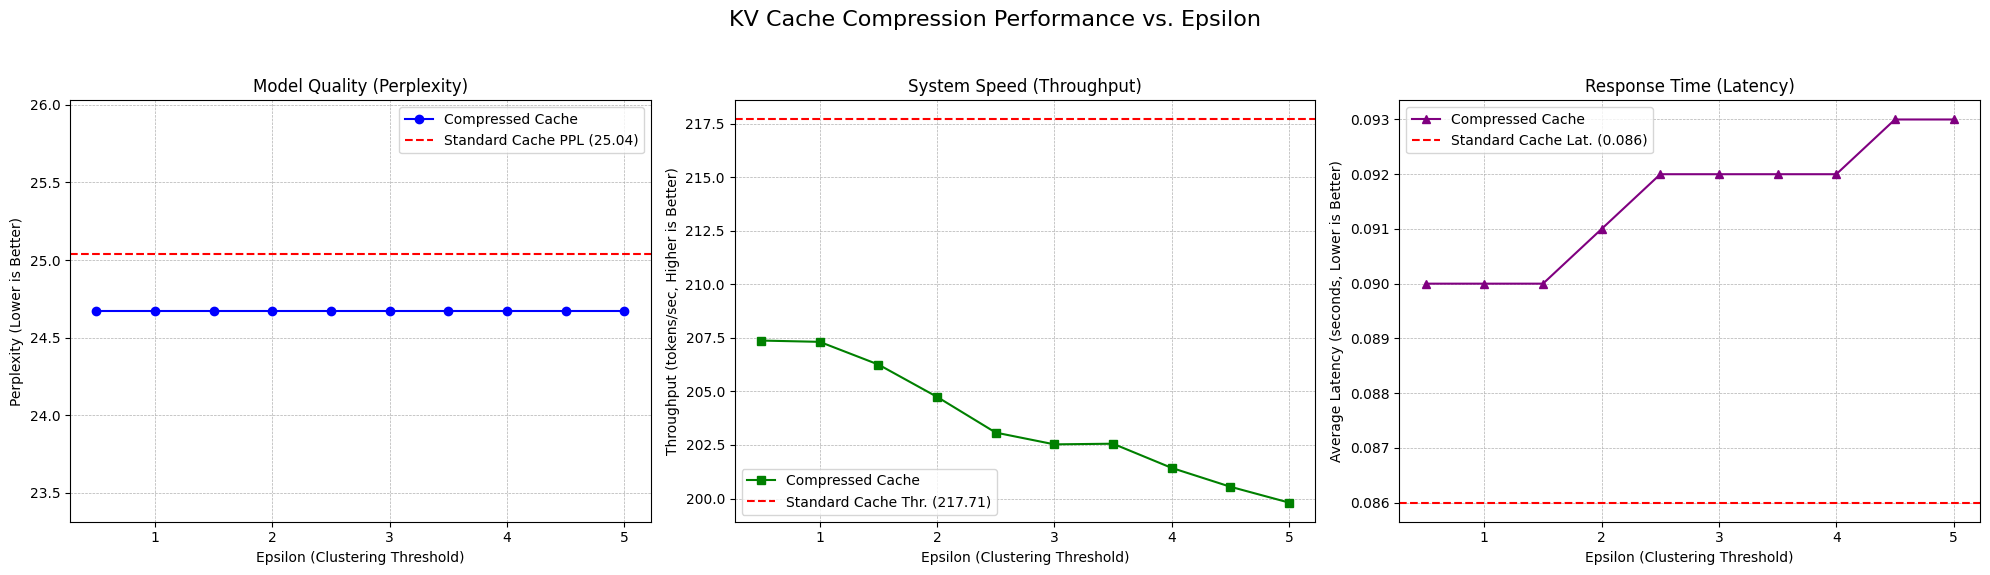

Full detailed experiment results saved to detailed_results_gpt2_20250911_133435.xlsx
Summary of experiment results saved to summary_results_gpt2_20250911_133435.xlsx

--- Saving Per-Layer KV Cache to FP32 hex .mem files for prefix: 'standard_cache' ---
  - Processing Layer 0 key (180480 entries) -> NEW_VERILOG_standard_cache_layer_0_key.mem
  - Processing Layer 0 value (180480 entries) -> NEW_VERILOG_standard_cache_layer_0_value.mem
  - Processing Layer 1 key (180480 entries) -> NEW_VERILOG_standard_cache_layer_1_key.mem
  - Processing Layer 1 value (180480 entries) -> NEW_VERILOG_standard_cache_layer_1_value.mem
  - Processing Layer 2 key (180480 entries) -> NEW_VERILOG_standard_cache_layer_2_key.mem
  - Processing Layer 2 value (180480 entries) -> NEW_VERILOG_standard_cache_layer_2_value.mem
  - Processing Layer 3 key (180480 entries) -> NEW_VERILOG_standard_cache_layer_3_key.mem
  - Processing Layer 3 value (180480 entries) -> NEW_VERILOG_standard_cache_layer_3_value.mem
  - Process

In [ ]:
run_full_experiment(gpt2_model, gpt2_tokenizer, prompt_texts[:10], name="gpt2")

In [35]:
# --- 1. Imports and Setup ---
import torch
import time
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.cache_utils import DynamicCache, Cache
import math

# --- 2. Utility Functions (Adapted from your new code) ---

def extract_kv_pairs(past_key_values: Cache) -> list:
    """Helper to extract a list of (k, v) 4D tensors from a Cache object or tuple."""
    if isinstance(past_key_values, tuple): # Handles standard GPT-2 format
        return list(past_key_values)
    # Handles modern Cache objects (e.g., for Llama)
    kv_pairs = []
    for layer_cache in past_key_values:
        kv_pairs.append(layer_cache)
    return kv_pairs

def rebuild_cache(pruned_kv_list: list, model_config) -> Cache:
    """Rebuilds a Cache object from a list of pruned (k,v) tensors."""
    is_llama = "llama" in model_config.model_type.lower()
    if is_llama:
        return DynamicCache.from_legacy_cache(past_key_values=tuple(pruned_kv_list))
    else: # For GPT-2, return a standard tuple
        return tuple(pruned_kv_list)

def save_tensors_to_mem_file(cache_data, prefix):
    """
    Saves K and V tensors for each layer into individual .mem files and returns the total count of values.
    """
    print(f"\n--- Saving Per-Layer KV Cache to .mem files for prefix: '{prefix}' ---")
    if not cache_data:
        print("  - No cache data provided.")
        return 0

    kv_pairs = extract_kv_pairs(cache_data)
    total_values_written = 0

    for i, (k_tensor, v_tensor) in enumerate(kv_pairs):
        tensors_to_process = {"key": k_tensor, "value": v_tensor}
        for tensor_name, tensor_data in tensors_to_process.items():
            filepath = f"{prefix}_layer_{i}_{tensor_name}.mem"
            flat_tensor = tensor_data.squeeze(0).flatten().to(torch.float32).cpu()
            num_values = len(flat_tensor)
            total_values_written += num_values
            print(f"  - Processing Layer {i} {tensor_name} ({num_values} entries) -> {filepath}")
            int32_representation = flat_tensor.view(torch.int32)
            with open(filepath, 'w') as f:
                for val in int32_representation:
                    hex_val = f'{(val.item() & 0xFFFFFFFF):08x}\n'
                    f.write(hex_val)

    print(f"--- .mem file export complete. Total values written: {total_values_written} ---")
    return total_values_written

# --- 3. Hybrid Pruning Module (Your new algorithm) ---
class HybridCompressionModule:
    """Combines Attention Sinks for stability with Graph Clustering for intelligent pruning."""
    def __init__(self, epsilon: float, num_sink_tokens: int, device: str, clustering_iterations=20):
        self.epsilon = epsilon
        self.num_sink_tokens = num_sink_tokens
        self.device = device
        self.clustering_iterations = clustering_iterations

    def _gpu_connected_components(self, adj_matrix):
        num_heads, seq_len, _ = adj_matrix.shape
        labels = torch.arange(seq_len, device=self.device, dtype=torch.long).unsqueeze(0).expand(num_heads, -1)
        adj_matrix_with_loops = adj_matrix | torch.eye(seq_len, device=self.device, dtype=torch.bool).unsqueeze(0)
        for _ in range(self.clustering_iterations):
            propagated_labels = torch.where(adj_matrix_with_loops, labels.unsqueeze(1), seq_len)
            min_neighbor_labels = torch.min(propagated_labels, dim=2).values
            new_labels = torch.min(labels, min_neighbor_labels)
            if torch.equal(labels, new_labels): break
            labels = new_labels
        return labels

    def _prune_kv_pair(self, k_state_4d, v_state_4d):
        _, num_heads, seq_len, head_dim = k_state_4d.shape
        if seq_len <= self.num_sink_tokens: return k_state_4d, v_state_4d
        k_sink, v_sink = k_state_4d[:, :, :self.num_sink_tokens, :], v_state_4d[:, :, :self.num_sink_tokens, :]
        k_prunable, v_prunable = k_state_4d[:, :, self.num_sink_tokens:, :], v_state_4d[:, :, self.num_sink_tokens:, :]
        k_prunable_3d, v_prunable_3d = k_prunable.squeeze(0), v_prunable.squeeze(0)
        prunable_seq_len = k_prunable_3d.shape[1]
        if prunable_seq_len <= 1: return k_state_4d, v_state_4d
        
        distances = torch.cdist(k_prunable_3d, k_prunable_3d)
        adjacency_matrix = distances < self.epsilon
        labels = self._gpu_connected_components(adjacency_matrix)
        
        max_components = 0
        remapped_labels_list = []
        for h in range(num_heads):
            unique, inverse = torch.unique(labels[h], return_inverse=True)
            remapped_labels_list.append(inverse)
            if unique.numel() > max_components: max_components = unique.numel()
        remapped_labels = torch.stack(remapped_labels_list)
        
        remapped_labels_exp = remapped_labels.unsqueeze(-1).expand(-1, -1, head_dim)
        centroids_sum_k = torch.zeros((num_heads, max_components, head_dim), dtype=k_prunable_3d.dtype, device=self.device)
        centroids_sum_v = torch.zeros_like(centroids_sum_k)
        counts = torch.zeros((num_heads, max_components), device=self.device, dtype=torch.long)
        
        counts.scatter_add_(1, remapped_labels, torch.ones_like(remapped_labels))
        centroids_sum_k.scatter_add_(1, remapped_labels_exp, k_prunable_3d)
        centroids_sum_v.scatter_add_(1, remapped_labels_exp, v_prunable_3d)
        
        counts = counts.unsqueeze(-1).clamp(min=1)
        centroids_k, centroids_v = centroids_sum_k / counts, centroids_sum_v / counts
        
        final_k = torch.cat([k_sink, centroids_k.unsqueeze(0)], dim=2)
        final_v = torch.cat([v_sink, centroids_v.unsqueeze(0)], dim=2)
        return final_k, final_v

    def compress_kv_cache(self, past_key_values: Cache) -> list:
        kv_pairs = extract_kv_pairs(past_key_values)
        return [self._prune_kv_pair(k, v) for k, v in kv_pairs]

# --- 4. Main Experiment Function ---
def run_full_experiment(model, tokenizer, prompt_texts, name="model"):
    """
    Runs the cache compression and saving process for a single prompt.
    """
    # --- Configuration ---
    if not prompt_texts:
        print("Error: The 'prompt_texts' list is empty. Cannot proceed.")
        return

    DEVICE = model.device
    selected_prompt = prompt_texts[0] # Use the first prompt from the list

    # Hyperparameters from your request
    EPSILON = 40.0
    COMPRESSION_INTERVAL = 8
    NUM_SINK_TOKENS = 4
    MAX_NEW_TOKENS = 50

    print("="*60)
    print(f"🚀 Starting KV Cache Export Process for '{name}'")
    print(f"Device: {DEVICE}")
    print(f"Prompt: '{selected_prompt}'")
    print(f"Compression Params: Epsilon={EPSILON}, Interval={COMPRESSION_INTERVAL}")
    print("="*60)

    # --- Step 1: Generate and Save Uncompressed (Baseline) Cache ---
    print("\n--- Generating BASELINE (Standard Cache) ---")
    inputs = tokenizer(selected_prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        standard_outputs = model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS, use_cache=True, return_dict_in_generate=True
        )
    standard_cache_values = save_tensors_to_mem_file(
        standard_outputs.past_key_values, f"{name}_standard_cache"
    )

    # --- Step 2: Generate and Save Compressed Cache ---
    print("\n--- Generating with HYBRID COMPRESSION ---")
    compression_module = HybridCompressionModule(EPSILON, NUM_SINK_TOKENS, DEVICE)
    
    generated_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    past_key_values = None
    
    with torch.no_grad():
        for step in range(MAX_NEW_TOKENS):
            model_inputs = {'input_ids': generated_ids[:, -1:] if past_key_values else generated_ids,
                            'past_key_values': past_key_values, 'use_cache': True,
                            'attention_mask': attention_mask}
            outputs = model(**model_inputs)
            next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(-1)
            if next_token.item() == tokenizer.eos_token_id: break
            generated_ids = torch.cat([generated_ids, next_token], dim=1)
            attention_mask = torch.cat([attention_mask, torch.ones((1, 1), device=DEVICE)], dim=1)
            past_key_values = outputs.past_key_values
            
            if (step + 1) % COMPRESSION_INTERVAL == 0:
                print(f"-> Compressing at step {step + 1}...")
                pruned_list = compression_module.compress_kv_cache(past_key_values)
                past_key_values = rebuild_cache(pruned_list, model.config)
                new_seq_len = past_key_values[0][0].shape[2]
                attention_mask = torch.ones((1, new_seq_len), device=DEVICE, dtype=torch.long)

    compressed_cache_values = save_tensors_to_mem_file(
        past_key_values, f"{name}_compressed_cache_eps{int(EPSILON)}"
    )

    # --- Step 3: Calculate and Print Savings ---
    print("\n" + "="*60)
    print("📊 Final Results")
    print("="*60)
    if standard_cache_values > 0 and compressed_cache_values > 0:
        saving_percentage = (1 - (compressed_cache_values / standard_cache_values)) * 100
        print(f"Total values in standard cache:    {standard_cache_values}")
        print(f"Total values in compressed cache:  {compressed_cache_values}")
        print(f"Memory Saving Percentage:          {saving_percentage:.2f}%")
    else:
        print("Could not calculate savings. One of the cache runs produced no values.")

In [36]:
run_full_experiment(gpt2_model, gpt2_tokenizer, prompt_texts[:1], name="gpt2")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


🚀 Starting KV Cache Export Process for 'gpt2'
Device: cuda:1
Prompt: 'Boulter starred in two films in 2008 , Daylight Robbery by filmmaker Paris Leonti , and Donkey Punch directed by Olly Blackburn . Boulter portrayed a character named " Sean " in Donkey Punch , who tags along with character " Josh " as the " quiet brother ... who hits it off with Tammi " . Boulter guest starred on a two @-@ part episode arc " Wounds " in May 2008 of the television series Waking the Dead as character " Jimmy Dearden " . He appeared on the television series Survivors as " Neil " in November 2008 . He had a recurring role in ten episodes of the television series Casualty in 2010 , as " Kieron Fletcher " . He portrayed an emergency physician applying for a medical fellowship . He commented on the inherent difficulties in portraying a physician on television : " Playing a doctor is a strange experience . Pretending you know what you 're talking about when you don 't is very bizarre but there are advisers o

In [ ]:
// tb_ram.v
`timescale 1ns / 1ps

module tb_ram;

    // Parameters for the test
    localparam DATA_WIDTH = 32;
    localparam ADDR_WIDTH = 22;
    localparam CLK_PERIOD = 10; // Clock period for a 100MHz clock

    // Testbench signals
    reg                      clk;
    reg                      we;
    reg     [ADDR_WIDTH-1:0] addr;
    reg     [DATA_WIDTH-1:0] din;
    wire    [DATA_WIDTH-1:0] dout;

    // Instantiate the memory module (your design file)
    memory_module #(
        .DATA_WIDTH(DATA_WIDTH),
        .ADDR_WIDTH(ADDR_WIDTH)
    ) uut (
        .clk(clk),
        .we(we),
        .addr(addr),
        .din(din),
        .dout(dout)
    );

    // Clock generator
    initial begin
        clk = 0;
        forever #(CLK_PERIOD/2) clk = ~clk;
    end

    // Test sequence
    initial begin
        // --- Step 1: Load the memory file ---
        // The simulator will look for this file in the project's
        // "simulation" or main run directory.
        // !! IMPORTANT: Change the filename here to match the file you want to test !!
        // For example, use "Verilog_standard_cache_all_keys.mem"
        // or "Verilog_compressed_cache_eps1.5_all_keys.mem"
        
        $readmemh("Verilog_standard_cache_all_keys.mem", uut.ram);

        // Display a message to confirm loading
        $display("Time: %0t ns | Memory initialized from file.", $time);

        // --- Step 2: Set signals for reading ---
        we   = 1'b0; // Disable writing to read from memory
        addr = 0;
        din  = 0;

        // Wait a full clock cycle
        #(CLK_PERIOD);

        // --- Step 3: Read back the first 10 values to verify ---
        $display("Time: %0t ns | --- Reading back first 10 values ---", $time);
        repeat (10) begin
            @(posedge clk);
            $display("Time: %0t ns | Addr: %d, Data Read: %h", $time, addr, dout);
            addr <= addr + 1;
        end

        // --- Step 4: Finish the simulation ---
        $display("Time: %0t ns | --- Test finished ---", $time);
        $finish;
    end

endmodule

STANDARD CACHE LAYER 0 --- KEY

STANDARD CACHE LAYER 0 --- VALUE

In [1]:
############## MEMORY HW

In [ ]:
`timescale 1ns / 1ps
//////////////////////////////////////////////////////////////////////////////////
// Company: 
// Engineer: 
// 
// Create Date: 09/11/2025 06:15:44 PM
// Design Name: 
// Module Name: memory_module
// Project Name: 
// Target Devices: 
// Tool Versions: 
// Description: 
// 
// Dependencies: 
// 
// Revision:
// Revision 0.01 - File Created
// Additional Comments:
// 
//////////////////////////////////////////////////////////////////////////////////


module memory_module #(
    parameter DATA_WIDTH = 32,
    parameter ADDR_WIDTH = 18
    )(
        input clk,
        input we,
        input [ADDR_WIDTH-1:0] addr,
        input [DATA_WIDTH-1:0] din,
        output reg [DATA_WIDTH-1:0] dout
    );
    
    localparam MEM_DEPTH = 1 << ADDR_WIDTH;
    
    reg [DATA_WIDTH-1:0] ram[MEM_DEPTH-1:0];
    
    always @(posedge clk) begin
        if (we) begin
            ram[addr] <= din;
        end
    end
    
    always @(posedge clk) begin
        dout <= ram[addr];
     end
 
endmodule


In [ ]:
`timescale 1ns / 1ps
//////////////////////////////////////////////////////////////////////////////////
// Company: 
// Engineer: 
// 
// Create Date: 09/11/2025 06:25:46 PM
// Design Name: 
// Module Name: tb_memory_module
// Project Name: 
// Target Devices: 
// Tool Versions: 
// Description: 
// 
// Dependencies: 
// 
// Revision:
// Revision 0.01 - File Created
// Additional Comments:
// 
//////////////////////////////////////////////////////////////////////////////////


module tb_memory_module;    

    // Parameters for the test
    localparam DATA_WIDTH = 32;
    localparam ADDR_WIDTH = 18;
    localparam CLK_PERIOD = 10; // Clock period for a 100MHz clock

    // Testbench signals
    reg                      clk;
    reg                      we;
    reg     [ADDR_WIDTH-1:0] addr;
    reg     [DATA_WIDTH-1:0] din;
    wire    [DATA_WIDTH-1:0] dout;

    // Instantiate the memory module (your design file)
    memory_module #(
        .DATA_WIDTH(DATA_WIDTH),
        .ADDR_WIDTH(ADDR_WIDTH)
    ) uut (
        .clk(clk),
        .we(we),
        .addr(addr),
        .din(din),
        .dout(dout)
    );

    // Clock generator
    initial begin
        clk = 0;
        forever #(CLK_PERIOD/2) clk = ~clk;
    end

    // Test sequence
    initial begin
        // --- Step 1: Load the memory file ---
        // The simulator will look for this file in the project's
        // "simulation" or main run directory.
        // !! IMPORTANT: Change the filename here to match the file you want to test !!
        // For example, use "Verilog_standard_cache_all_keys.mem"
        // or "Verilog_compressed_cache_eps1.5_all_keys.mem"
        
        $readmemh("NEW_VERILOG_compressed_cache_eps1.5_layer_0_value.mem", uut.ram);

        // Display a message to confirm loading
        $display("Time: %0t ns | Memory initialized from file.", $time);

        // --- Step 2: Set signals for reading ---
        we   = 1'b0; // Disable writing to read from memory
        addr = 0;
        din  = 0;

        // Wait a full clock cycle
        #(CLK_PERIOD);

        // --- Step 3: Read back the first 10 values to verify ---
        $display("Time: %0t ns | --- Reading back first 10 values ---", $time);
        repeat (10) begin
            @(posedge clk);
            $display("Time: %0t ns | Addr: %d, Data Read: %h", $time, addr, dout);
            addr <= addr + 1;
        end

        // --- Step 4: Finish the simulation ---
        $display("Time: %0t ns | --- Test finished ---", $time);
        $finish;
    end

endmodule
